In [ ]:
import pandas as pd
import sklearn as sk
import os
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,mean_absolute_error
from sklearn.model_selection import train_test_split
import math
import matplotlib.pyplot as plt
import myConfig
os.chdir(myConfig.absPath)
import numpy as np
def regression_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    """
    Вычисляет три основные метрики для регрессии:
    - MAE (Mean Absolute Error): средняя абсолютная ошибка в исходном масштабе
    - RMSE (Root Mean Squared Error): корень из среднеквадратичной ошибки
    - MAPE (Mean Absolute Percentage Error): средняя абсолютная процентная ошибка (%)
    """
    mae = mean_absolute_error(y_true, y_pred)
    rmse = math.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / np.clip(np.abs(y_true), 1e-8, None))) * 100
    return {"MAE": mae, "RMSE": rmse, "MAPE": mape}


In [2]:
dataset = pd.read_csv("data\\StudentPerformanceFactors_prepared.csv")
dataset

,Gender_Male,Gender_Female,Learning_Disabilities_Yes,Learning_Disabilities_No,Distance_from_Home_Near,Distance_from_Home_Moderate,Distance_from_Home_Far,Parental_Education_Level_Postgraduate,Parental_Education_Level_High School,Parental_Education_Level_College,...,Parental_Involvement_Medium,Parental_Involvement_Low,Parental_Involvement_High,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,23,84,7,73,0,3,67
1,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,19,64,8,59,2,4,61
2,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,24,98,7,91,2,4,74
3,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,29,89,8,98,1,4,71
4,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,0.0,19,92,6,65,3,4,70
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6373,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,25,69,7,76,1,2,68
6374,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,23,76,8,81,3,2,69
6375,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,20,90,6,65,3,2,68
6376,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,1.0,10,86,6,91,2,3,68


In [ ]:
features = dataset.columns.to_list()
features.remove("Exam_Score")
X_train, X_test, y_train, y_test = train_test_split(dataset[features], dataset["Exam_Score"], test_size=0.3, random_state=myConfig.random_state)



In [4]:
baseline = LinearRegression()
baseline.fit(X_train,y_train)
baseline.score(X_test,y_test)


0.7341788060614416

In [5]:
y_pred = baseline.predict(X_test)
regression_metrics(y_test,y_pred)

{'MAE': 0.48658306758588943,
 'RMSE': 2.016667467774464,
 'MAPE': np.float64(0.6659332116826675)}

In [6]:
y_test

2718    74
4275    66
4141    70
1199    72
4546    67
        ..
1071    69
718     66
6048    67
4622    66
1505    68
Name: Exam_Score, Length: 1914, dtype: int64

In [7]:
y_pred

array([73.98629944, 65.9862952 , 70.46370116, ..., 67.11761777,
       65.76543417, 68.18062883], shape=(1914,))

In [8]:
baseline.coef_

array([ 0.00632831, -0.00632831, -0.4314907 ,  0.4314907 ,  0.47817713,
       -0.04008021, -0.43809692,  0.49635749, -0.49187824, -0.00447925,
        0.48262063,  0.0475201 , -0.53014073,  0.0347127 , -0.0347127 ,
       -0.0557359 , -0.47844828,  0.53418418, -0.03522726, -0.54647346,
        0.58170072,  0.42706722, -0.42706722, -0.0222581 , -0.58732487,
        0.60958297,  0.29262815, -0.29262815, -0.01315583, -1.02971348,
        1.04286931, -0.02611443, -1.00497802,  1.03109246,  0.29613044,
        0.19795015, -0.01669028,  0.048559  ,  0.47380155,  0.1983892 ])

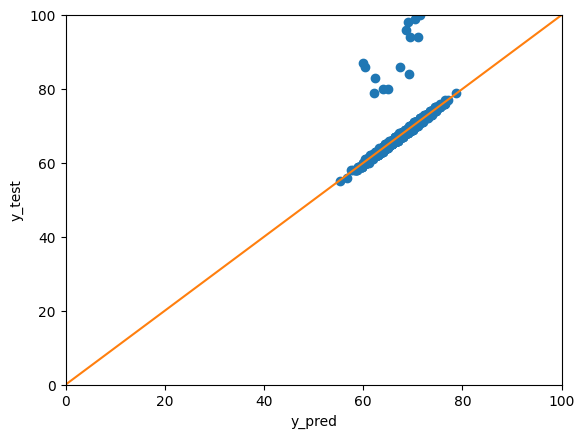

In [9]:
plt.plot(y_pred,y_test,"o")
plt.xlabel("y_pred")
plt.ylabel("y_test")
plt.xlim((0,100))
plt.ylim((0,100))
plt.plot((0,100),(0,100))
plt.show()

In [10]:
import pickle
pickle.dump(baseline, open("artifacts\\regression.sav", 'wb'))